# LESSON 6.4: Adaptive Filters and Periodic Noise Reduction
## Image Restoration

In this lesson:
- Adaptive local noise reduction filter
- Adaptive median filter for heavy salt-and-pepper noise
- Periodic noise reduction using frequency domain filtering
- Band-reject filters
- Band-pass filters
- Notch filters for surgical frequency removal

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Adaptive Local Noise Reduction Filter

Fixed-parameter filters (mean, median) apply the **same operation** everywhere. But different image regions may need different treatment:

- **Smooth regions**: aggressive smoothing is safe (no edges to destroy)
- **Edge regions**: smoothing should be minimal (preserve edge sharpness)

### The Adaptive Filter (Gonzalez, Section 5.3.3):

$$\hat{f}(x,y) = g(x,y) - \frac{\sigma_\eta^2}{\sigma_L^2}\left[g(x,y) - m_L\right]$$

Where:
- $g(x,y)$ = pixel value in the degraded image
- $\sigma_\eta^2$ = **noise variance** (estimated or known)
- $\sigma_L^2$ = **local variance** in the neighborhood $S_{xy}$
- $m_L$ = **local mean** in the neighborhood $S_{xy}$

### Behavior:
- If $\sigma_\eta^2 = 0$ (no noise): $\hat{f} = g$ (no change)
- If $\sigma_L^2 = \sigma_\eta^2$ (uniform region, variance = noise): $\hat{f} = m_L$ (full averaging)
- If $\sigma_L^2 \gg \sigma_\eta^2$ (edge region, high local variance): $\hat{f} \approx g$ (minimal smoothing)

### Key insight:
The ratio $\sigma_\eta^2 / \sigma_L^2$ automatically adjusts the **strength of smoothing** based on the local content.

In [2]:
# Helper functions

def create_test_image(size=256):
    """Create a synthetic biomedical phantom image."""
    img = np.ones((size, size), dtype=np.float64) * 30
    Y, X = np.mgrid[0:size, 0:size]
    cx, cy = size // 2, size // 2
    
    body = ((X - cx) / 100) ** 2 + ((Y - cy) / 80) ** 2 <= 1
    img[body] = 120
    organ1 = ((X - cx + 30) / 35) ** 2 + ((Y - cy + 10) / 45) ** 2 <= 1
    img[organ1] = 170
    organ2 = ((X - cx - 35) / 25) ** 2 + ((Y - cy - 15) / 30) ** 2 <= 1
    img[organ2] = 80
    for (sx, sy, sr) in [(cx-20, cy+30, 5), (cx+40, cy-25, 4), (cx-50, cy-20, 3)]:
        spot = (X - sx) ** 2 + (Y - sy) ** 2 <= sr ** 2
        img[spot] = 240
    return img


def compute_psnr(original, restored):
    """Compute PSNR in dB."""
    mse = np.mean((original - restored) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0 ** 2 / mse)


def arithmetic_mean_filter(image, kernel_size=3):
    """Simple arithmetic mean filter."""
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(M):
        for j in range(N):
            result[i, j] = np.mean(padded[i:i+kernel_size, j:j+kernel_size])
    return result


def median_filter(image, kernel_size=3):
    """Median filter."""
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(M):
        for j in range(N):
            result[i, j] = np.median(padded[i:i+kernel_size, j:j+kernel_size])
    return result


original = create_test_image(256)
print("Helper functions defined.")

Helper functions defined.


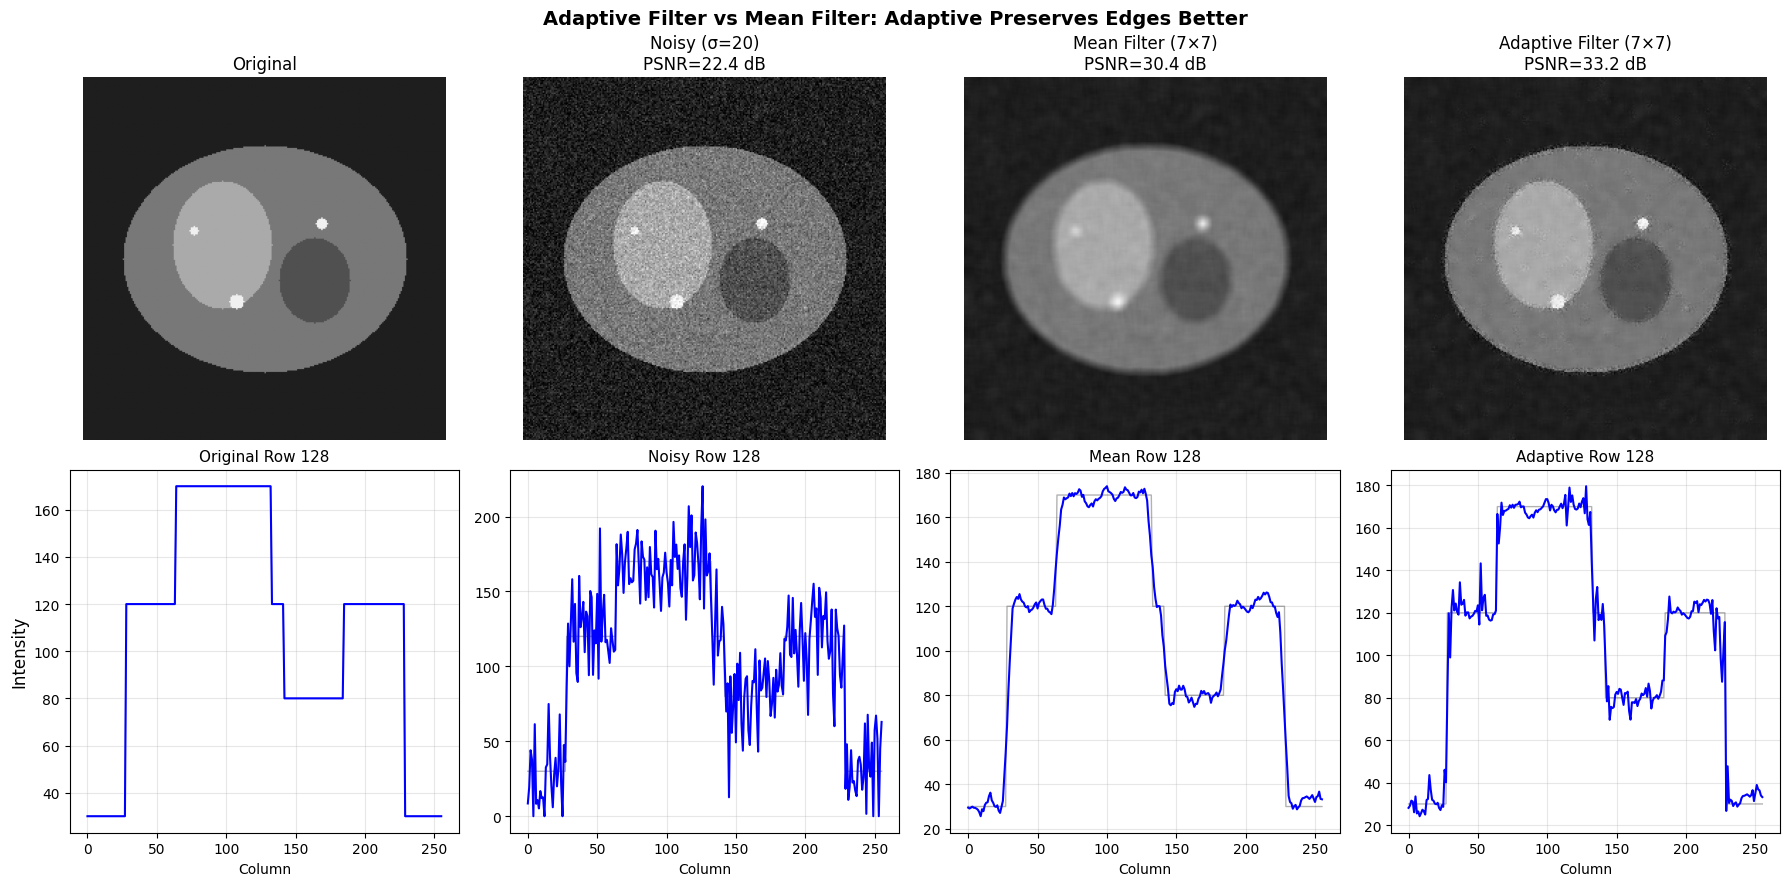

The adaptive filter smooths flat regions aggressively (like mean filter)
but preserves edges by reducing smoothing where local variance is high.


In [3]:
# Implement the Adaptive Local Noise Reduction Filter

def adaptive_local_filter(image, kernel_size=7, noise_variance=None):
    """
    Adaptive local noise reduction filter.
    
    f_hat(x,y) = g(x,y) - (sigma_n^2 / sigma_L^2) * (g(x,y) - m_L)
    
    Parameters:
        image: noisy image g(x,y)
        kernel_size: size of local neighborhood
        noise_variance: estimated noise variance (if None, estimated from image)
    Returns:
        Filtered image
    """
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    
    # Estimate noise variance if not provided
    if noise_variance is None:
        # Use a flat region to estimate noise variance
        noise_variance = np.var(image[10:60, 10:60])
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            local_mean = np.mean(region)
            local_var = np.var(region)
            
            # Ensure local_var >= noise_variance to avoid negative ratio
            if local_var < noise_variance:
                result[i, j] = local_mean  # fully smooth
            else:
                ratio = noise_variance / local_var
                result[i, j] = image[i, j] - ratio * (image[i, j] - local_mean)
    
    return np.clip(result, 0, 255)


# Apply to Gaussian noise
np.random.seed(42)
sigma_noise = 20
noisy = np.clip(original + np.random.normal(0, sigma_noise, original.shape), 0, 255)

restored_mean = arithmetic_mean_filter(noisy, 7)
restored_adaptive = adaptive_local_filter(noisy, 7, noise_variance=sigma_noise**2)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title(f'Noisy (σ={sigma_noise})\nPSNR={compute_psnr(original, noisy):.1f} dB', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(restored_mean, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title(f'Mean Filter (7×7)\nPSNR={compute_psnr(original, restored_mean):.1f} dB', fontsize=12)
axes[0, 2].axis('off')

axes[0, 3].imshow(restored_adaptive, cmap='gray', vmin=0, vmax=255)
axes[0, 3].set_title(f'Adaptive Filter (7×7)\nPSNR={compute_psnr(original, restored_adaptive):.1f} dB', fontsize=12)
axes[0, 3].axis('off')

# Intensity profiles
row = 128
for i, (img, label) in enumerate([
    (original, 'Original'), (noisy, 'Noisy'),
    (restored_mean, 'Mean'), (restored_adaptive, 'Adaptive')]):
    axes[1, i].plot(original[row, :], 'k-', alpha=0.3, linewidth=1)
    axes[1, i].plot(img[row, :], 'b-', linewidth=1.5)
    axes[1, i].set_title(f'{label} Row {row}', fontsize=11)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlabel('Column')

axes[1, 0].set_ylabel('Intensity', fontsize=12)

plt.suptitle('Adaptive Filter vs Mean Filter: Adaptive Preserves Edges Better',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The adaptive filter smooths flat regions aggressively (like mean filter)")
print("but preserves edges by reducing smoothing where local variance is high.")

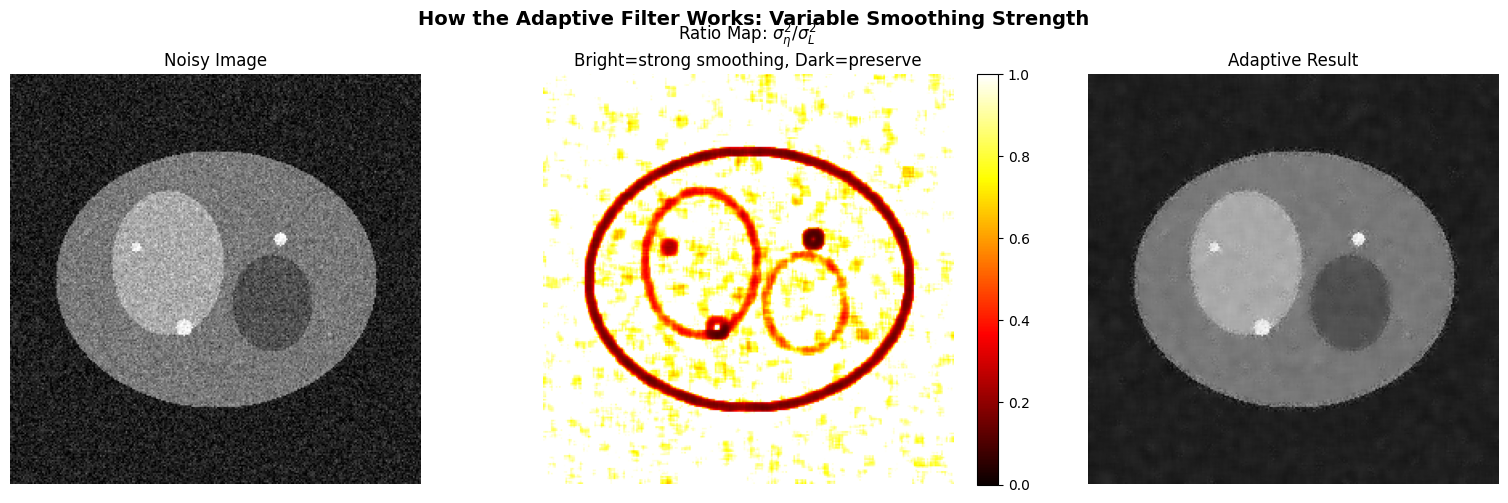

Bright regions in ratio map = high smoothing (flat areas)
Dark regions in ratio map = minimal smoothing (edges, boundaries)


In [4]:
# Visualize the adaptive filter's behavior: show the ratio map

def compute_ratio_map(image, kernel_size=7, noise_variance=400):
    """Compute the sigma_n^2 / sigma_L^2 ratio map."""
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    ratio_map = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            local_var = np.var(region)
            if local_var < noise_variance:
                ratio_map[i, j] = 1.0  # full smoothing
            else:
                ratio_map[i, j] = noise_variance / local_var
    
    return ratio_map


ratio_map = compute_ratio_map(noisy, 7, sigma_noise**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(noisy, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Noisy Image', fontsize=12)
axes[0].axis('off')

im = axes[1].imshow(ratio_map, cmap='hot', vmin=0, vmax=1)
axes[1].set_title('Ratio Map: $\\sigma_\\eta^2 / \\sigma_L^2$\n'
                   'Bright=strong smoothing, Dark=preserve', fontsize=12)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(restored_adaptive, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Adaptive Result', fontsize=12)
axes[2].axis('off')

plt.suptitle('How the Adaptive Filter Works: Variable Smoothing Strength',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Bright regions in ratio map = high smoothing (flat areas)")
print("Dark regions in ratio map = minimal smoothing (edges, boundaries)")

---
## 2. Adaptive Median Filter

The standard median filter uses a **fixed** window size. If noise density is very high (>20%), a fixed-size median filter may not be effective.

The **Adaptive Median Filter** (Gonzalez, Section 5.3.4) uses a **variable window size** that grows until:
1. The median is not an impulse (not 0 or 255)
2. Or the maximum window size $S_{\max}$ is reached

### Algorithm:

**Level A** (Check if median is valid):
- $A_1 = z_{\text{med}} - z_{\min}$
- $A_2 = z_{\text{med}} - z_{\max}$
- If $A_1 > 0$ AND $A_2 < 0$: median is **not an impulse** → go to Level B
- Else: increase window size and repeat Level A
- If window reaches $S_{\max}$: output $z_{\text{med}}$

**Level B** (Check if current pixel is valid):
- $B_1 = z_{xy} - z_{\min}$
- $B_2 = z_{xy} - z_{\max}$
- If $B_1 > 0$ AND $B_2 < 0$: pixel is **not an impulse** → output $z_{xy}$ (preserve)
- Else: pixel is an impulse → output $z_{\text{med}}$ (replace)

### Advantages over standard median:
- Handles **higher noise densities** (up to ~50% salt-and-pepper)
- **Preserves detail** better because non-impulse pixels are kept unchanged
- Window size adapts to local noise density

In [5]:
# Implement the Adaptive Median Filter

def adaptive_median_filter(image, max_size=7):
    """
    Adaptive median filter with variable window size.
    
    Parameters:
        image: noisy image
        max_size: maximum window size (must be odd)
    Returns:
        Filtered image
    """
    M, N = image.shape
    max_pad = max_size // 2
    padded = np.pad(image, max_pad, mode='reflect')
    result = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            # Start with 3×3 window
            window_size = 3
            z_xy = image[i, j]
            
            while window_size <= max_size:
                pad = window_size // 2
                # Extract region from padded image
                ri = i + max_pad - pad
                rj = j + max_pad - pad
                region = padded[ri:ri+window_size, rj:rj+window_size]
                
                z_min = np.min(region)
                z_max = np.max(region)
                z_med = np.median(region)
                
                # Level A: Check if median is valid
                A1 = z_med - z_min
                A2 = z_med - z_max
                
                if A1 > 0 and A2 < 0:
                    # Median is not an impulse
                    # Level B: Check if current pixel is valid
                    B1 = z_xy - z_min
                    B2 = z_xy - z_max
                    
                    if B1 > 0 and B2 < 0:
                        result[i, j] = z_xy  # keep original
                    else:
                        result[i, j] = z_med  # replace with median
                    break
                else:
                    # Median might be an impulse, increase window
                    window_size += 2
            
            if window_size > max_size:
                result[i, j] = z_med  # use median at max size
    
    return np.clip(result, 0, 255)


print("Adaptive median filter function defined.")

Adaptive median filter function defined.


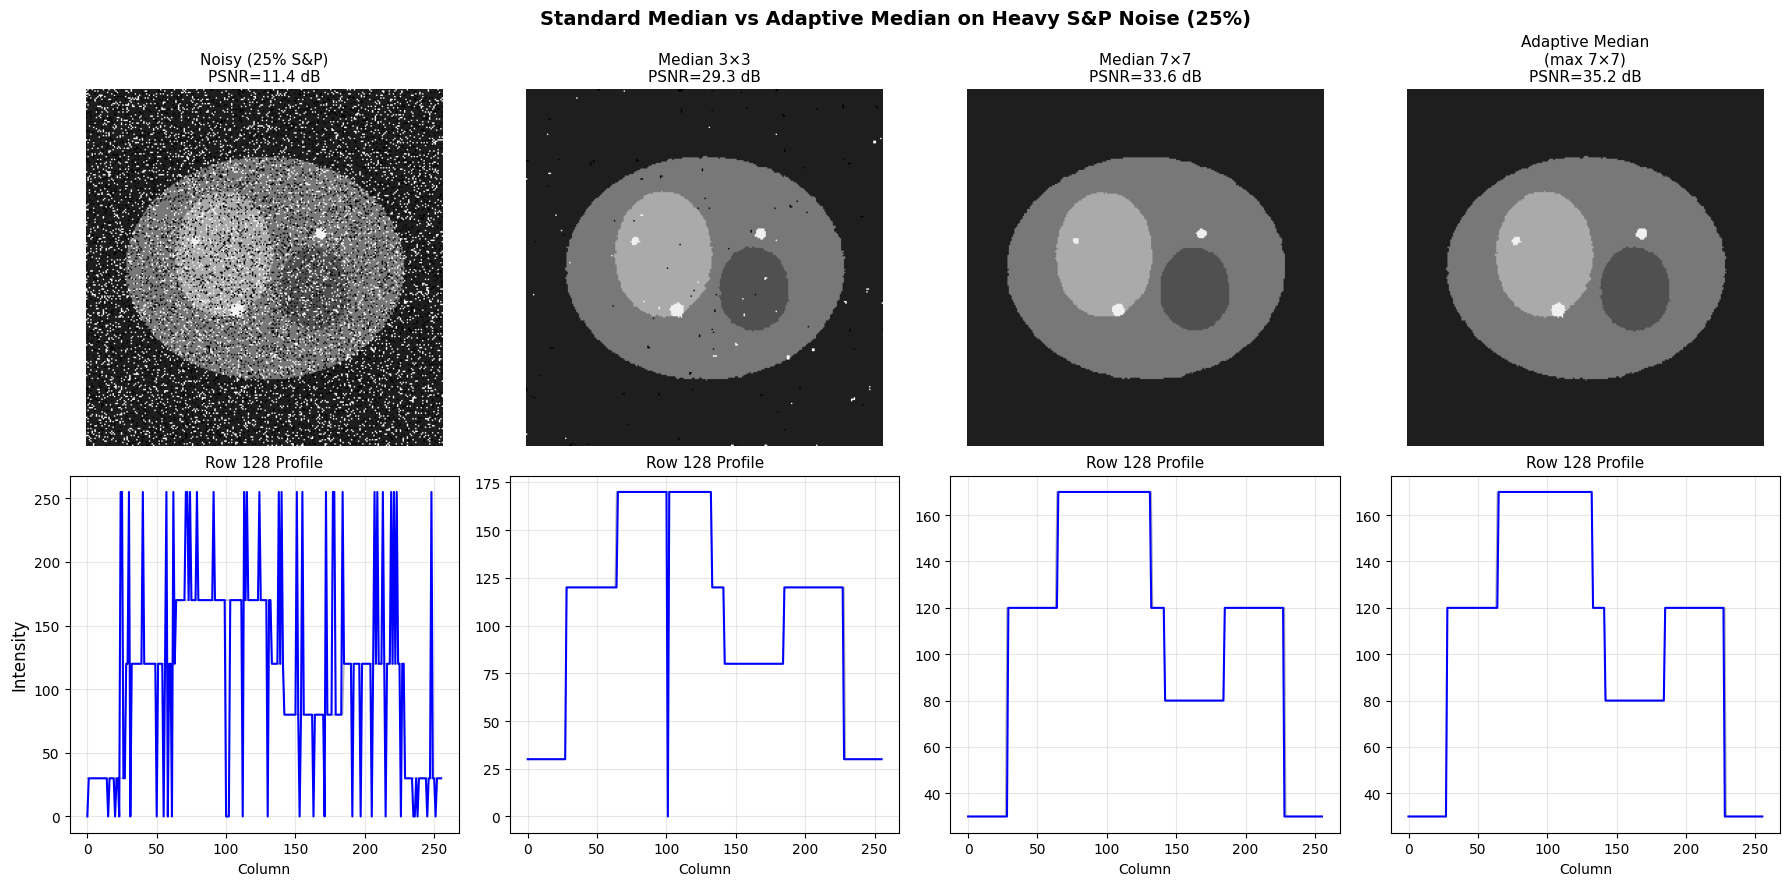

3×3 Median: Cannot handle 25% noise density — residual impulses remain
7×7 Median: Removes noise but OVER-SMOOTHS the image (edges lost)
Adaptive Median: Best of both worlds — removes noise AND preserves edges


In [6]:
# Compare standard vs adaptive median on heavy salt-and-pepper noise

def add_salt_pepper_noise(image, prob_salt=0.05, prob_pepper=0.05):
    """Add salt-and-pepper noise."""
    noisy = image.copy()
    total = image.size
    num_salt = int(prob_salt * total)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    num_pepper = int(prob_pepper * total)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy


# Heavy salt-and-pepper noise (25% total)
np.random.seed(42)
noisy_heavy = add_salt_pepper_noise(original, 0.125, 0.125)

# Standard median with different sizes
restored_med3 = median_filter(noisy_heavy, 3)
restored_med7 = median_filter(noisy_heavy, 7)

# Adaptive median
restored_adaptive_med = adaptive_median_filter(noisy_heavy, max_size=7)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

images = [noisy_heavy, restored_med3, restored_med7, restored_adaptive_med]
titles = ['Noisy (25% S&P)', 'Median 3×3', 'Median 7×7', 'Adaptive Median\n(max 7×7)']

for i, (img, title) in enumerate(zip(images, titles)):
    psnr = compute_psnr(original, img)
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'{title}\nPSNR={psnr:.1f} dB', fontsize=11)
    axes[0, i].axis('off')
    
    row = 128
    axes[1, i].plot(original[row, :], 'k-', alpha=0.3, linewidth=1)
    axes[1, i].plot(img[row, :], 'b-', linewidth=1.5)
    axes[1, i].set_title(f'Row {row} Profile', fontsize=11)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlabel('Column')

axes[1, 0].set_ylabel('Intensity', fontsize=12)

plt.suptitle('Standard Median vs Adaptive Median on Heavy S&P Noise (25%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("3×3 Median: Cannot handle 25% noise density — residual impulses remain")
print("7×7 Median: Removes noise but OVER-SMOOTHS the image (edges lost)")
print("Adaptive Median: Best of both worlds — removes noise AND preserves edges")

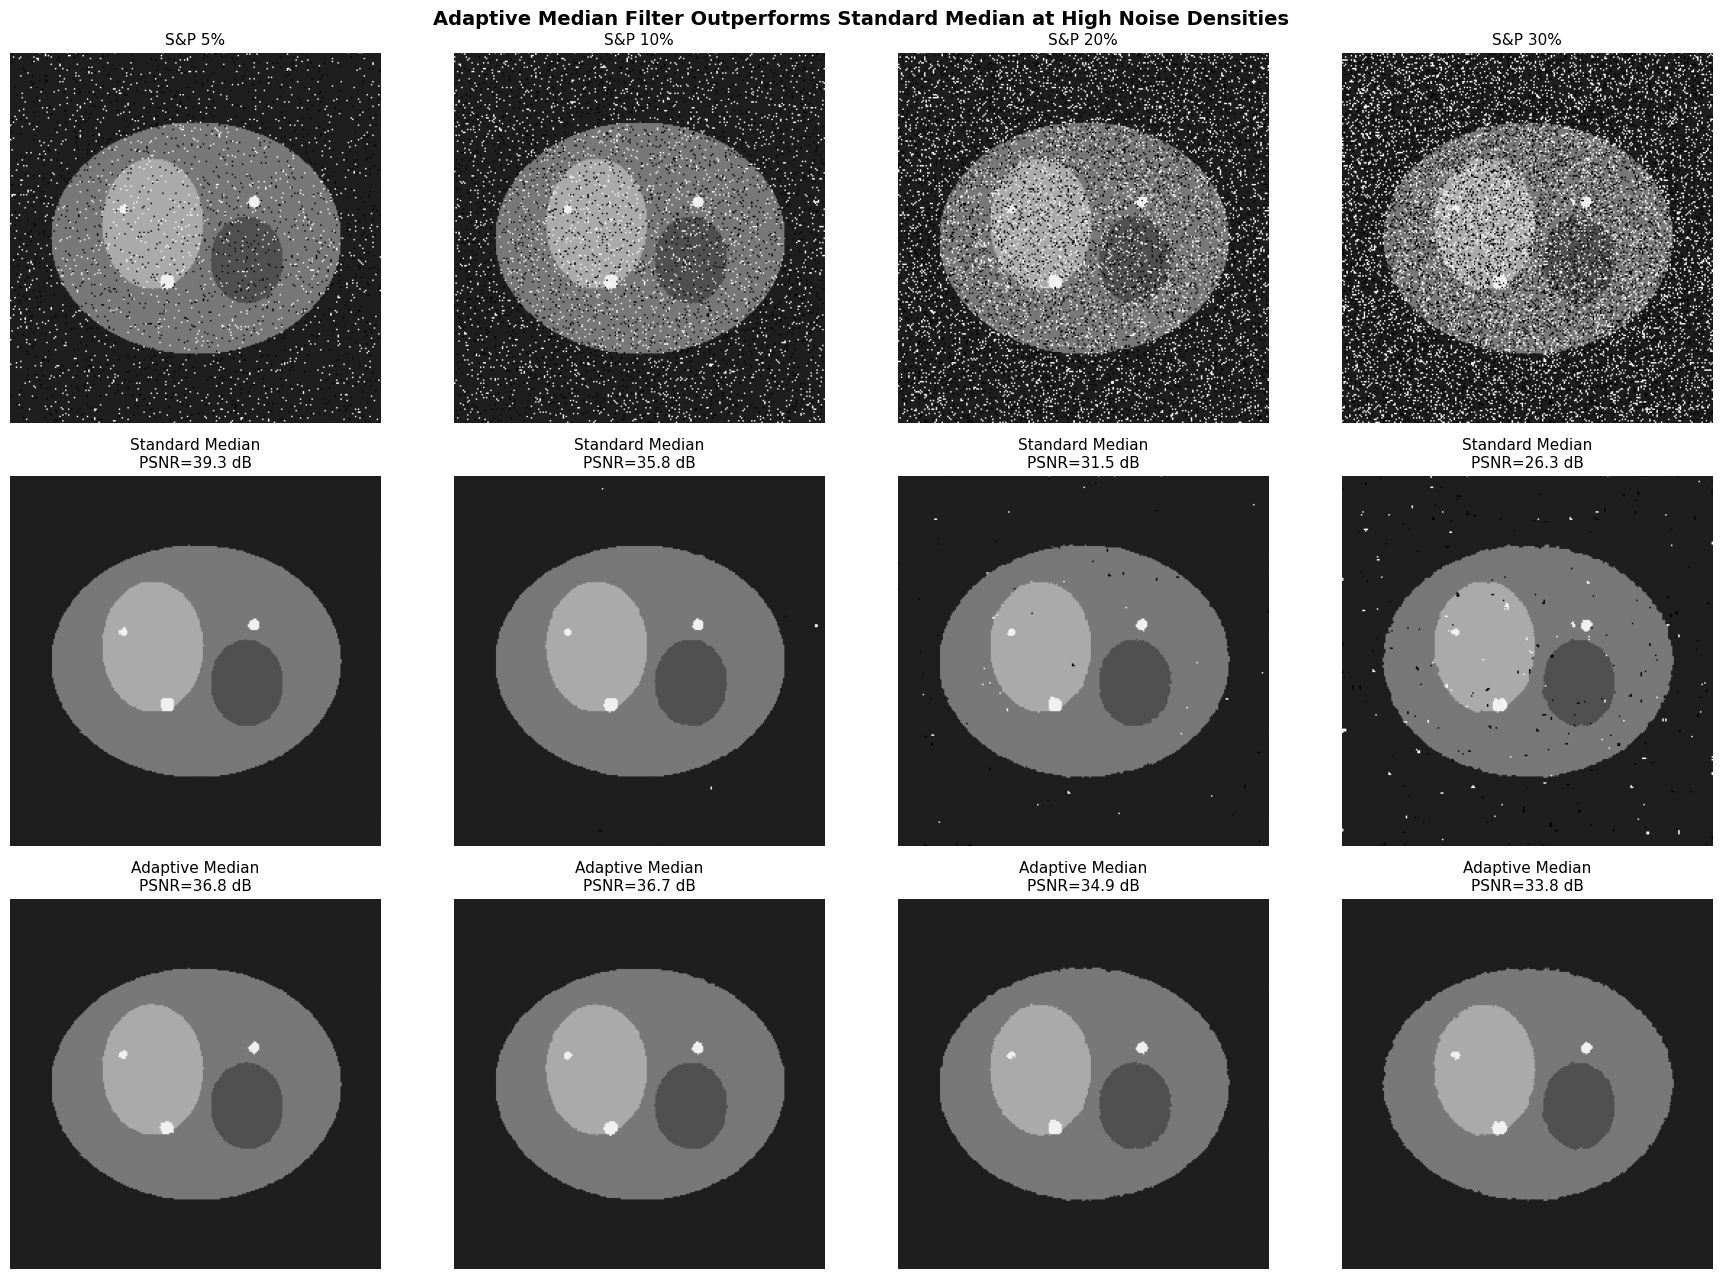

In [7]:
# Show performance across different noise densities
noise_probs = [0.05, 0.1, 0.2, 0.3]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))

for i, prob in enumerate(noise_probs):
    np.random.seed(42)
    noisy_img = add_salt_pepper_noise(original, prob/2, prob/2)
    
    restored_std = median_filter(noisy_img, 3)
    restored_adp = adaptive_median_filter(noisy_img, max_size=7)
    
    axes[0, i].imshow(noisy_img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'S&P {int(prob*100)}%', fontsize=11)
    axes[0, i].axis('off')
    
    psnr_std = compute_psnr(original, restored_std)
    axes[1, i].imshow(restored_std, cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'Standard Median\nPSNR={psnr_std:.1f} dB', fontsize=11)
    axes[1, i].axis('off')
    
    psnr_adp = compute_psnr(original, restored_adp)
    axes[2, i].imshow(restored_adp, cmap='gray', vmin=0, vmax=255)
    axes[2, i].set_title(f'Adaptive Median\nPSNR={psnr_adp:.1f} dB', fontsize=11)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Noisy', fontsize=12)
axes[1, 0].set_ylabel('Standard\nMedian 3×3', fontsize=12)
axes[2, 0].set_ylabel('Adaptive\nMedian', fontsize=12)

plt.suptitle('Adaptive Median Filter Outperforms Standard Median at High Noise Densities',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Periodic Noise Reduction: Frequency Domain Filters

Periodic noise appears as **discrete spikes** in the frequency spectrum. These can be removed using frequency domain filters.

### 3.1 Band-Reject Filter

Removes a **band (ring)** of frequencies centered at distance $D_0$ from the origin with bandwidth $W$:

**Ideal Band-Reject:**
$$H(u,v) = \begin{cases} 0 & \text{if } D_0 - W/2 \leq D(u,v) \leq D_0 + W/2 \\ 1 & \text{otherwise} \end{cases}$$

**Gaussian Band-Reject:**
$$H(u,v) = 1 - e^{-\frac{1}{2}\left[\frac{D^2(u,v) - D_0^2}{D(u,v) \cdot W}\right]^2}$$

**Butterworth Band-Reject (order $n$):**
$$H(u,v) = \frac{1}{1 + \left[\frac{D(u,v) \cdot W}{D^2(u,v) - D_0^2}\right]^{2n}}$$

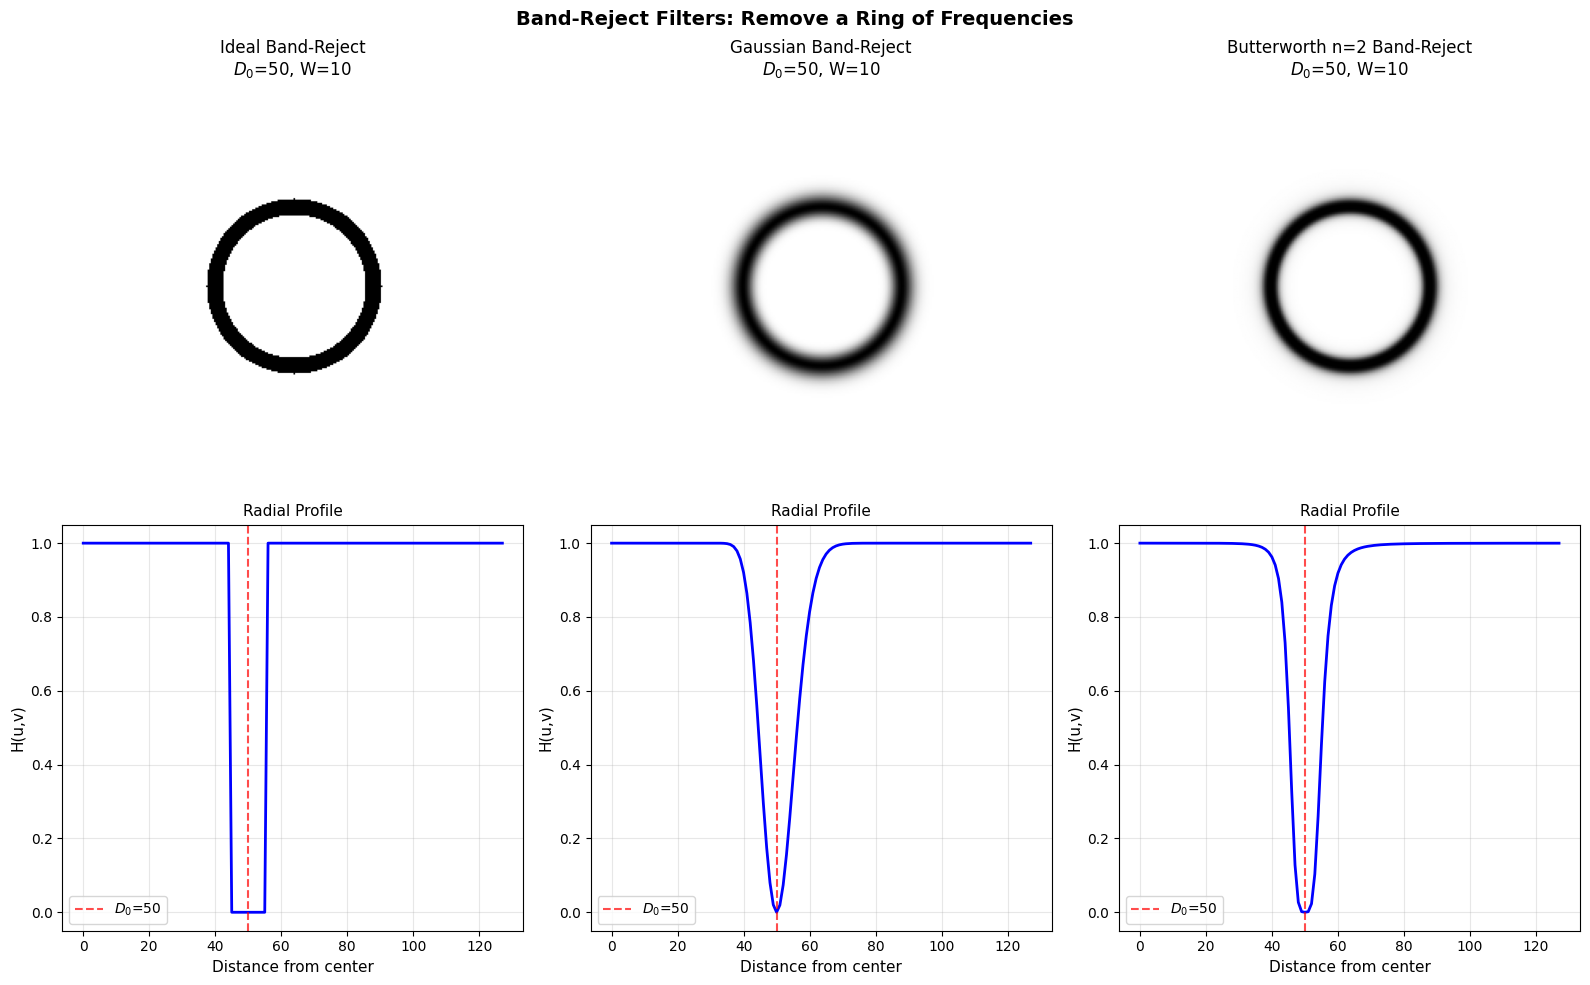

In [8]:
# Implement band-reject filters

def create_distance_matrix(P, Q):
    """Create distance matrix D(u,v) from center."""
    u = np.arange(P)
    v = np.arange(Q)
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt((U - P/2)**2 + (V - Q/2)**2)
    return D


def ideal_bandreject(P, Q, D0, W):
    """Ideal band-reject filter."""
    D = create_distance_matrix(P, Q)
    H = np.ones((P, Q), dtype=np.float64)
    H[(D >= D0 - W/2) & (D <= D0 + W/2)] = 0
    return H


def gaussian_bandreject(P, Q, D0, W):
    """Gaussian band-reject filter."""
    D = create_distance_matrix(P, Q)
    # Avoid division by zero
    DW = np.maximum(D * W, 1e-10)
    H = 1 - np.exp(-0.5 * ((D**2 - D0**2) / DW)**2)
    return H


def butterworth_bandreject(P, Q, D0, W, n=2):
    """Butterworth band-reject filter of order n."""
    D = create_distance_matrix(P, Q)
    D2_minus_D02 = D**2 - D0**2
    # Avoid division by zero
    D2_minus_D02 = np.where(np.abs(D2_minus_D02) < 1e-10, 1e-10, D2_minus_D02)
    H = 1.0 / (1.0 + (D * W / D2_minus_D02)**(2*n))
    return H


# Visualize band-reject filters
P, Q = 256, 256
D0, W = 50, 10

H_ideal = ideal_bandreject(P, Q, D0, W)
H_gauss = gaussian_bandreject(P, Q, D0, W)
H_butter = butterworth_bandreject(P, Q, D0, W, n=2)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, (H, title) in enumerate([(H_ideal, 'Ideal'), (H_gauss, 'Gaussian'), (H_butter, 'Butterworth n=2')]):
    axes[0, i].imshow(H, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'{title} Band-Reject\n$D_0$={D0}, W={W}', fontsize=12)
    axes[0, i].axis('off')
    
    # Radial profile
    center = P // 2
    axes[1, i].plot(H[center, center:], 'b-', linewidth=2)
    axes[1, i].axvline(x=D0, color='r', linestyle='--', alpha=0.7, label=f'$D_0$={D0}')
    axes[1, i].set_xlabel('Distance from center', fontsize=11)
    axes[1, i].set_ylabel('H(u,v)', fontsize=11)
    axes[1, i].set_title('Radial Profile', fontsize=11)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].legend()

plt.suptitle('Band-Reject Filters: Remove a Ring of Frequencies',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 3.2 Notch Filters

Notch filters are the most **targeted** frequency domain tool. They reject frequencies at **specific points** rather than entire rings.

A **notch reject filter** removes frequency pairs at $(u_0, v_0)$ and $(-u_0, -v_0)$ (symmetrically, to maintain real output):

**Gaussian Notch Reject:**
$$H(u,v) = 1 - e^{-D_1^2(u,v)/(2D_0^2)} \cdot e^{-D_2^2(u,v)/(2D_0^2)}$$

Where:
- $D_1(u,v)$ = distance from $(u,v)$ to the notch center $(u_0, v_0)$
- $D_2(u,v)$ = distance from $(u,v)$ to the symmetric notch $(-u_0, -v_0)$
- $D_0$ = notch radius (controls how much surrounding frequency is affected)

### Advantages:
- **Surgical**: removes only the offending frequencies
- **Minimal distortion**: most of the spectrum is untouched
- **Perfect for periodic noise**: targets the exact interference frequencies

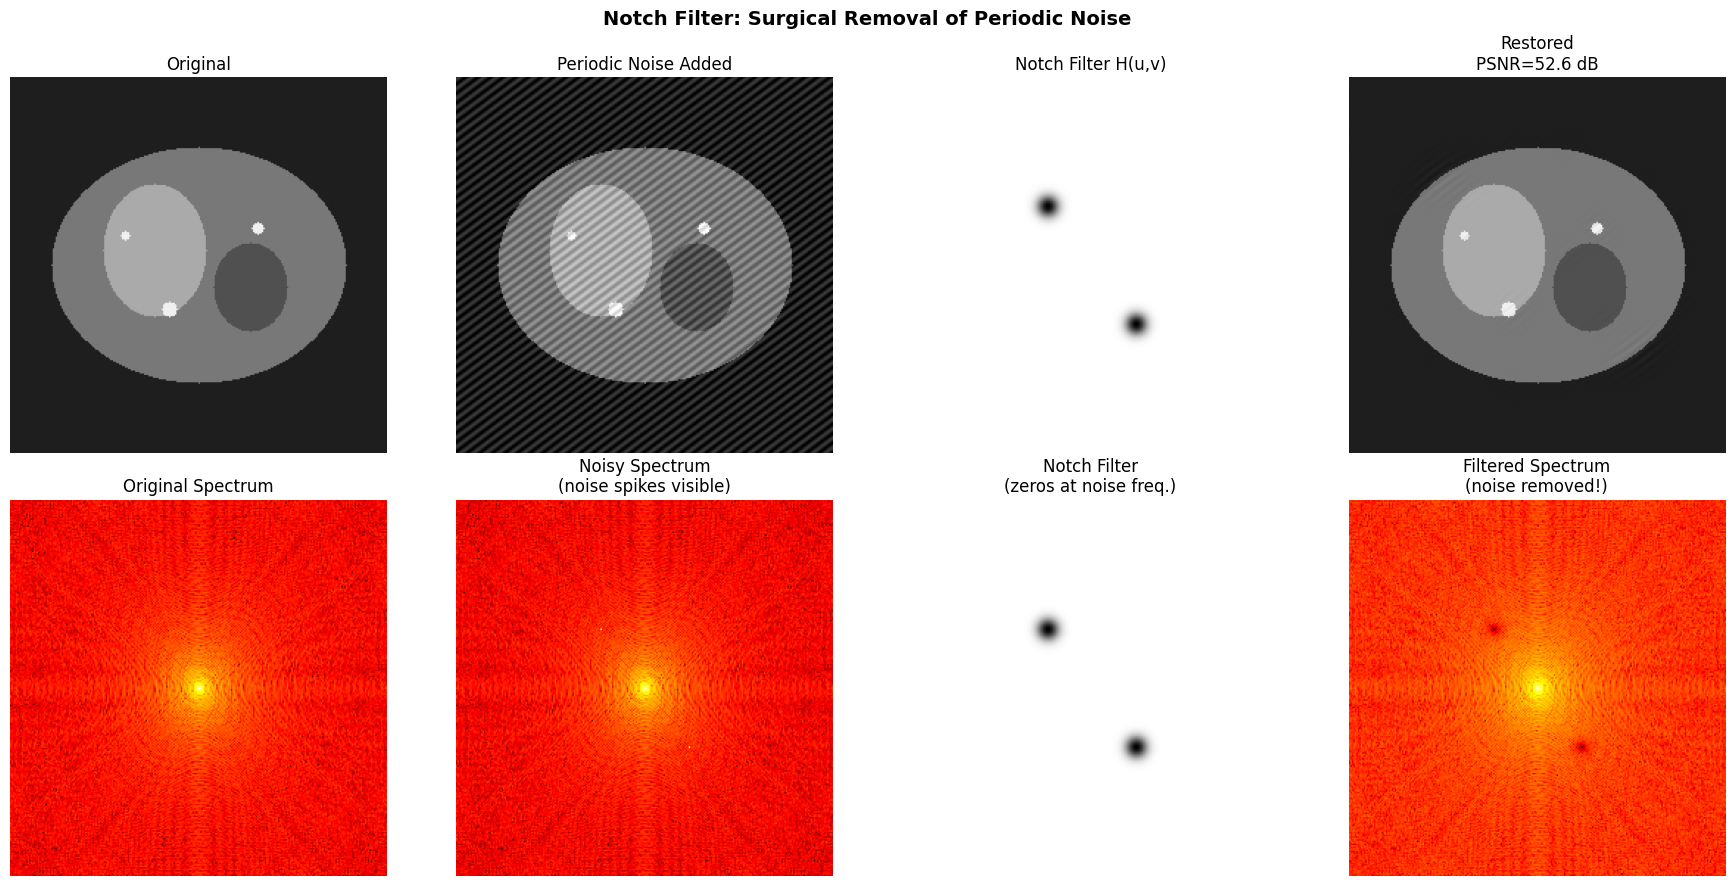

Degraded PSNR: 21.6 dB
Restored PSNR: 52.6 dB
The notch filter almost perfectly removes the periodic interference!


In [9]:
# Implement notch filters

def gaussian_notch_reject(P, Q, notch_centers, D0=10):
    """
    Gaussian notch reject filter.
    
    Parameters:
        P, Q: image dimensions
        notch_centers: list of (u0, v0) notch center coordinates
                       (relative to center of spectrum)
        D0: notch radius
    Returns:
        Filter H(u,v)
    """
    u = np.arange(P)
    v = np.arange(Q)
    U, V = np.meshgrid(u, v, indexing='ij')
    
    H = np.ones((P, Q), dtype=np.float64)
    cx, cy = P // 2, Q // 2
    
    for u0, v0 in notch_centers:
        # Notch at (cx+u0, cy+v0) and symmetric at (cx-u0, cy-v0)
        D1 = np.sqrt((U - (cx + u0))**2 + (V - (cy + v0))**2)
        D2 = np.sqrt((U - (cx - u0))**2 + (V - (cy - v0))**2)
        
        H *= (1 - np.exp(-D1**2 / (2 * D0**2))) * (1 - np.exp(-D2**2 / (2 * D0**2)))
    
    return H


# Create image with periodic noise
M, N = original.shape
Y, X = np.mgrid[0:M, 0:N]

# Add periodic noise at known frequencies
u0, v0 = 30, 40
noise_periodic = 30 * np.sin(2 * np.pi * u0 * X / N + 2 * np.pi * v0 * Y / M)
noisy_periodic = np.clip(original + noise_periodic, 0, 255)

# Create notch filter at the noise frequencies
H_notch = gaussian_notch_reject(M, N, [(v0, u0)], D0=5)

# Apply notch filter
F = np.fft.fftshift(np.fft.fft2(noisy_periodic))
G = H_notch * F
restored_notch = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
restored_notch = np.clip(restored_notch, 0, 255)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Spatial domain
axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_periodic, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Periodic Noise Added', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(H_notch, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title('Notch Filter H(u,v)', fontsize=12)
axes[0, 2].axis('off')

axes[0, 3].imshow(restored_notch, cmap='gray', vmin=0, vmax=255)
axes[0, 3].set_title(f'Restored\nPSNR={compute_psnr(original, restored_notch):.1f} dB', fontsize=12)
axes[0, 3].axis('off')

# Frequency domain
axes[1, 0].imshow(np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(original)))), cmap='hot')
axes[1, 0].set_title('Original Spectrum', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(np.log1p(np.abs(F)), cmap='hot')
axes[1, 1].set_title('Noisy Spectrum\n(noise spikes visible)', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(H_notch, cmap='gray')
axes[1, 2].set_title('Notch Filter\n(zeros at noise freq.)', fontsize=12)
axes[1, 2].axis('off')

axes[1, 3].imshow(np.log1p(np.abs(G)), cmap='hot')
axes[1, 3].set_title('Filtered Spectrum\n(noise removed!)', fontsize=12)
axes[1, 3].axis('off')

plt.suptitle('Notch Filter: Surgical Removal of Periodic Noise',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Degraded PSNR: {compute_psnr(original, noisy_periodic):.1f} dB")
print(f"Restored PSNR: {compute_psnr(original, restored_notch):.1f} dB")
print("The notch filter almost perfectly removes the periodic interference!")

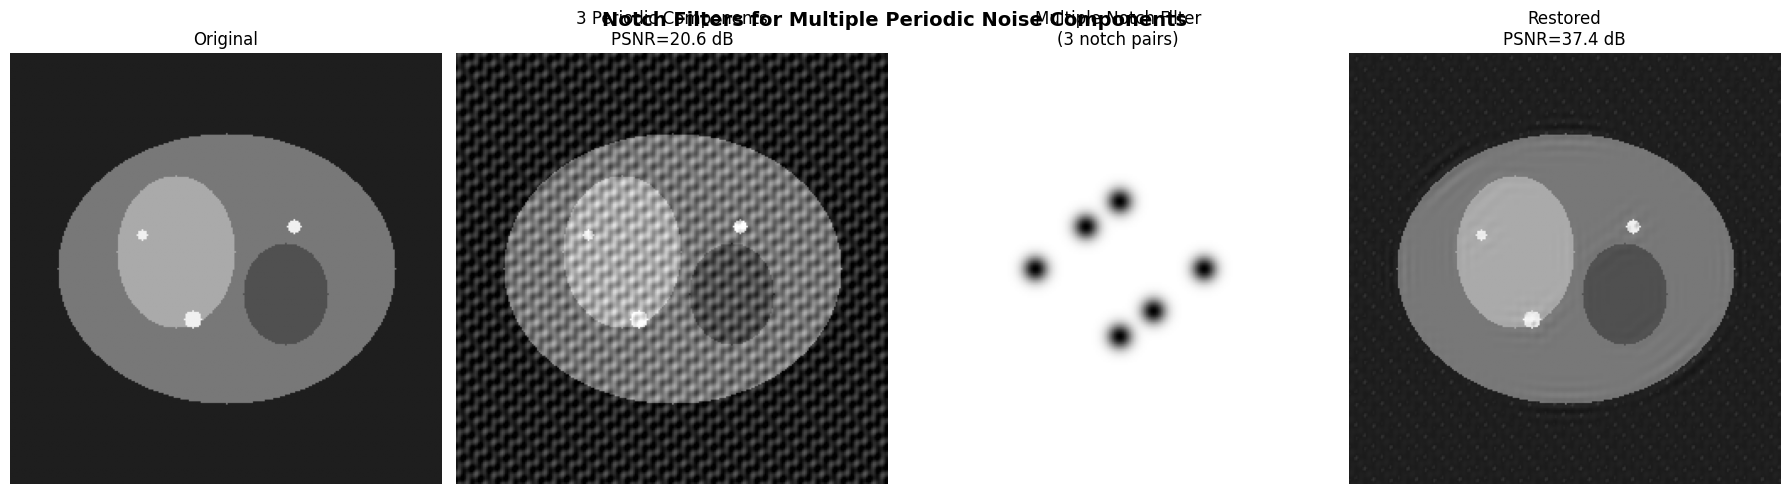

In [10]:
# Multiple periodic noise components — multiple notch filters

# Add multiple periodic interference patterns
noise_multi = (25 * np.sin(2 * np.pi * 20 * X / N + 2 * np.pi * 25 * Y / M) +
               20 * np.sin(2 * np.pi * 50 * X / N) +
               15 * np.cos(2 * np.pi * 40 * Y / M))
noisy_multi = np.clip(original + noise_multi, 0, 255)

# Create notch filter for all three interference frequencies
notch_centers = [(25, 20), (0, 50), (40, 0)]  # (v0, u0) pairs
H_multi = gaussian_notch_reject(M, N, notch_centers, D0=5)

# Apply filter
F_multi = np.fft.fftshift(np.fft.fft2(noisy_multi))
G_multi = H_multi * F_multi
restored_multi = np.real(np.fft.ifft2(np.fft.ifftshift(G_multi)))
restored_multi = np.clip(restored_multi, 0, 255)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(noisy_multi, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'3 Periodic Components\nPSNR={compute_psnr(original, noisy_multi):.1f} dB', fontsize=12)
axes[1].axis('off')

axes[2].imshow(H_multi, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Multiple Notch Filter\n(3 notch pairs)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(restored_multi, cmap='gray', vmin=0, vmax=255)
axes[3].set_title(f'Restored\nPSNR={compute_psnr(original, restored_multi):.1f} dB', fontsize=12)
axes[3].axis('off')

plt.suptitle('Notch Filters for Multiple Periodic Noise Components',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

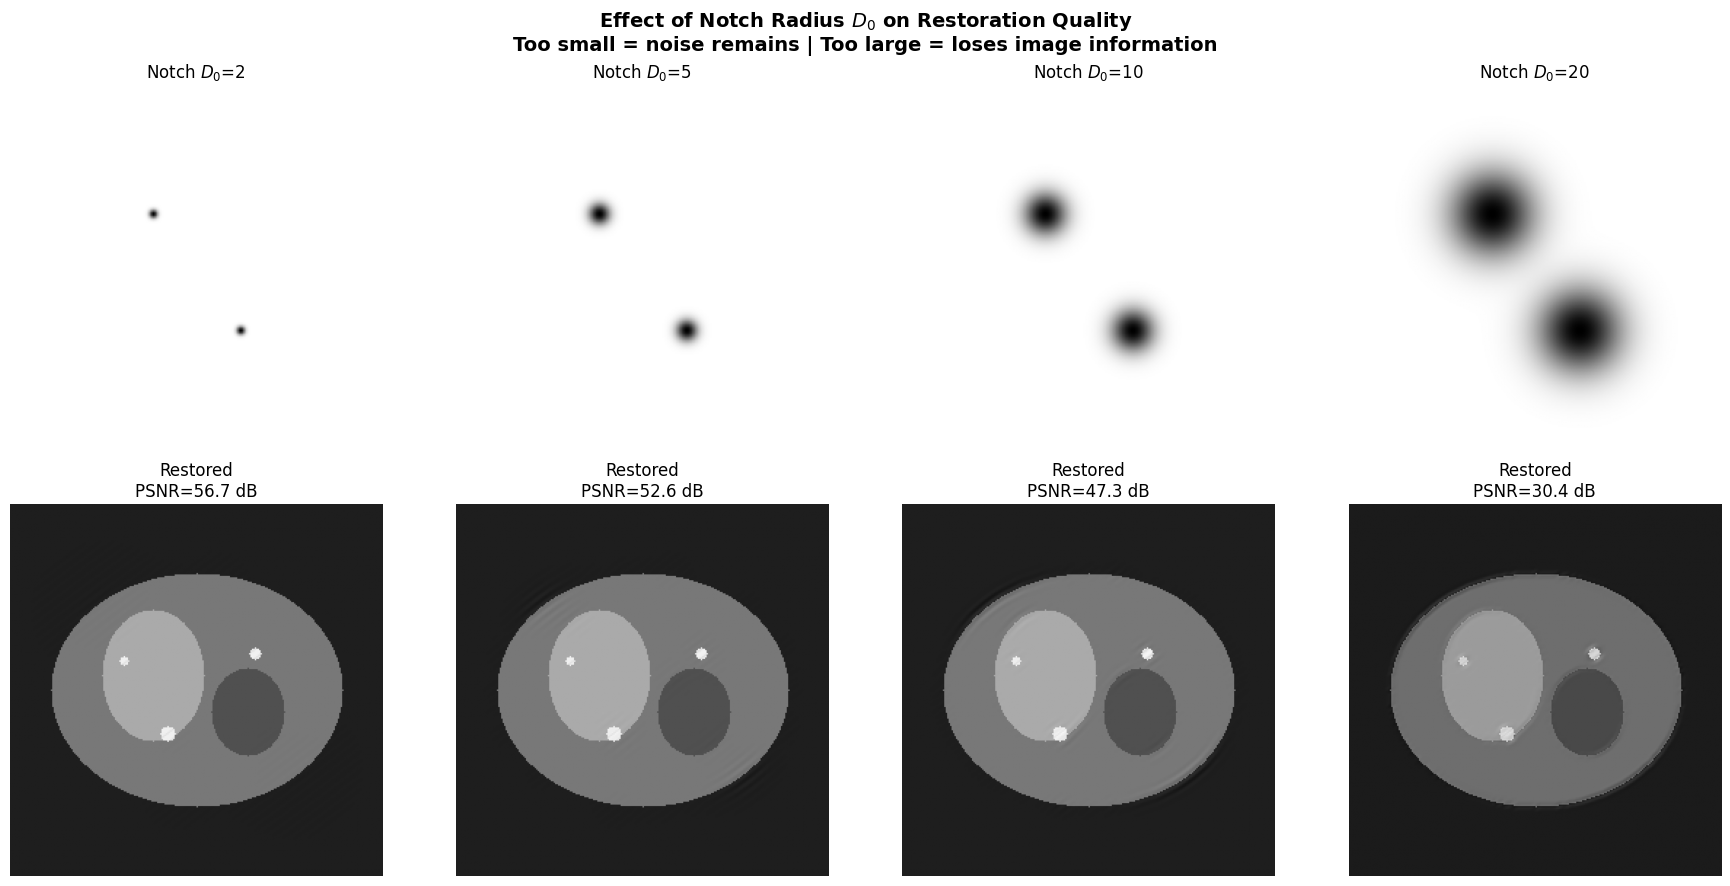

Small D0: Very targeted but may not fully remove the noise
Large D0: Removes noise completely but also removes nearby image frequencies
Best D0: Just large enough to cover the noise spike


In [11]:
# Effect of notch radius D0
D0_values = [2, 5, 10, 20]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, D0 in enumerate(D0_values):
    H = gaussian_notch_reject(M, N, [(v0, u0)], D0=D0)
    F = np.fft.fftshift(np.fft.fft2(noisy_periodic))
    restored = np.real(np.fft.ifft2(np.fft.ifftshift(H * F)))
    restored = np.clip(restored, 0, 255)
    psnr = compute_psnr(original, restored)
    
    axes[0, i].imshow(H, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Notch $D_0$={D0}', fontsize=12)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(restored, cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'Restored\nPSNR={psnr:.1f} dB', fontsize=12)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Filter', fontsize=12)
axes[1, 0].set_ylabel('Result', fontsize=12)

plt.suptitle('Effect of Notch Radius $D_0$ on Restoration Quality\n'
             'Too small = noise remains | Too large = loses image information',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Small D0: Very targeted but may not fully remove the noise")
print("Large D0: Removes noise completely but also removes nearby image frequencies")
print("Best D0: Just large enough to cover the noise spike")

---
## Summary

What we learned:

1. **Adaptive local noise reduction** adjusts smoothing based on local statistics:
   $\hat{f} = g - \frac{\sigma_\eta^2}{\sigma_L^2}(g - m_L)$. Smooth regions get full averaging; edges are preserved.

2. **Adaptive median filter** uses variable window size to handle high-density impulse noise (up to ~50% salt-and-pepper). It preserves non-impulse pixels unchanged.

3. **Band-reject filters** remove a ring of frequencies, useful when noise energy is concentrated at a known distance from the origin.

4. **Notch filters** surgically remove specific frequency pairs. They are the optimal tool for periodic noise because they cause minimal distortion to the rest of the spectrum.

5. **Notch radius $D_0$** controls the trade-off: too small leaves residual noise, too large removes image information.

6. Periodic noise identification: look for **bright impulse pairs** in the centered Fourier spectrum. Their positions reveal the interference frequencies.